# 4D-MAP Phase 2 Analysis — Plan A

Four figures, each with **3 lines** (baseline / delay / loss):

| Figure | Metric | Aggregation |
|--------|--------|-------------|
| Fig 1 | Bandwidth (Mbps) | mean per (t,path) → sum over paths |
| Fig 2 | OWD (ms) | per-path lines |
| Fig 3 | Utility U | mean per (t,path) → sum over paths |
| Fig 4 | Loss rate | mean per (t,path) → max over paths |

Colors: baseline / delay / loss. TC markers: `tc_delay` (red/orange, netem **delay ms**) on Fig 2 / panel D only; `tc_loss` (netem **loss %**) on Fig 4 / panel L — vertical lines on Fig 4 use **gray** (`TC_LOSS_VLINE_COLOR`); data lines unchanged. x = `at_sec` + offset (auto from logs unless overridden).
Set `PHASE2_LOG_ROOT` to your bundle (e.g. `logs_exp/log` with three `vm_run_*` dirs).


In [1]:
# Cell 0: install dependencies (run once, then restart kernel)
import subprocess, sys
ret = subprocess.call([sys.executable, '-m', 'pip', 'install',
                       'matplotlib', 'pandas', 'numpy', 'ipykernel', '-q'])
print('deps ok' if ret == 0 else f'pip exit {ret}')


deps ok



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 0. Log bundle: layout and line-style preview

Inspect raw files under `PHASE2_LOG_ROOT` before parsing:

- **`pull_*.log`** — client-side; lines tagged `[utility]` and `[m]monitor` are parsed by `parse_logs.py`.
- **`server_*.log`** — LAL / QUIC server; verbose; not used for Plan A plots.
- **`push_*.log`** — upload client; same tag styles as pull for multipath stats.
- **`tc_delay_*.log` / `tc_loss_*.log`** — short timeline from netem scripts (step times align plots).

**Note:** counting `[utility]` / `[m]monitor` lines scans the *entire* pull log (can take tens of seconds per large file).
**TC time alignment:** `at=` in tc logs is relative to the tc script; pull `t` is relative to the first `[utility]` line. The notebook estimates **offset ≈ t(first tc step) − t(first utility)** (wall times) and plots **`at_sec + offset`**. Override with **`TC_TIME_OFFSET_DELAY_SEC` / `TC_TIME_OFFSET_LOSS_SEC`** in the paths cell if needed.

**Why 20 ms → 80 ms → 150 ms at 0 s / 25 s / 50 s?** Those values come from the configured delay profile (e.g. `scripts/mininet/delay_profile.example.env` on Path B / `h1-eth1`): each line is `time_sec delay_ms`, so the experiment ramps delay at those step times—they are not arbitrary plot labels.



In [2]:
# Preview helpers (defines REPO here so this cell runs before the imports cell)
from collections import Counter
from pathlib import Path

REPO = Path("../..").resolve()
PHASE2_LOG_ROOT = REPO / "logs_exp/log"  # change if your bundle lives elsewhere


def classify_run_dir(d: Path) -> str:
    """Label a vm_run_* folder: baseline | delay | loss | unknown."""
    if list(d.glob("tc_delay_*.log")):
        return "delay"
    if list(d.glob("tc_loss_*.log")):
        return "loss"
    if next(d.glob("pull_*.log"), None):
        return "baseline"
    return "unknown"


def peek_lines(path: Path, max_lines: int = 25, encoding: str = "utf-8") -> list:
    """First lines with terminal color codes stripped."""
    import re
    esc = re.compile(r"\x1b\[[0-9;]*m")
    out = []
    if not path.is_file():
        return out
    with open(path, encoding=encoding, errors="replace") as f:
        for _ in range(max_lines):
            line = f.readline()
            if not line:
                break
            out.append(esc.sub("", line.rstrip()))
    return out


def count_substr(path: Path, substr: str) -> int:
    n = 0
    if not path.is_file():
        return 0
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            if substr in line:
                n += 1
    return n


run_dirs = sorted(PHASE2_LOG_ROOT.glob("vm_run_*"), key=lambda p: p.name)
print(f"PHASE2_LOG_ROOT = {PHASE2_LOG_ROOT}")
print(f"Found {len(run_dirs)} vm_run_* director(y/ies)\n")

for d in run_dirs:
    kind = classify_run_dir(d)
    print("=" * 72)
    print(f"{d.name}  →  kind={kind}")
    for f in sorted(d.iterdir()):
        if f.suffix == ".log":
            print(f"  {f.name}: {f.stat().st_size // 1024} KiB")
    pull = next(d.glob("pull_*.log"), None)
    if pull:
        u = count_substr(pull, "[utility]")
        m = count_substr(pull, "[m]monitor")
        print(f"  pull: lines with '[utility]' = {u:,}  '[m]monitor' = {m:,}")
        print("  pull sample (first 10 non-empty lines, width-truncated):")
        shown = 0
        for line in peek_lines(pull, 120):
            if not line.strip():
                continue
            print("   ", line[:200])
            shown += 1
            if shown >= 10:
                break
    for tc in sorted(d.glob("tc_*.log")):
        print(f"  --- {tc.name} (entire file) ---")
        print(open(tc, encoding="utf-8", errors="replace").read().rstrip())
    srv = next(d.glob("server_*.log"), None)
    if srv:
        print(f"  server: {count_substr(srv, 'INFO')} lines containing 'INFO' (illustrative)")
        print("  server sample:")
        for line in peek_lines(srv, 15)[:5]:
            if line.strip():
                print("   ", line[:200])
    print()


PHASE2_LOG_ROOT = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/log
Found 3 vm_run_* director(y/ies)

vm_run_20260402_165427  →  kind=baseline
  pull_20260402_165427.log: 83166 KiB
  push_20260402_165427.log: 109551 KiB
  server_20260402_165427.log: 204892 KiB
  pull: lines with '[utility]' = 192,790  '[m]monitor' = 192,790
  pull sample (first 10 non-empty lines, width-truncated):
    true rr /home/mininet/Videos/pulled_20260402_165427.flv true false false
    2026/04/02 16:54:30.802071 DEBUG protocol = quic - rtmpquic.go:36
    2026/04/02 16:54:30.802518 DEBUG [monitor]sess :<nil> - rtmpquic.go:44
    2026/04/02 16:54:30.803533  INFO [RTMPPULL1] lifecycle new rtmp ClientSession. session=0x4000148240 - client_session.go:135
    2026/04/02 16:54:30.803573 DEBUG [RTMPPULL1] Do. url=rtmp://10.0.1.2/live/test - client_session.go:141
    2026/04/02 16:54:30.804623  INFO [RTMPPULL1] > tcp connect. protocol:quic - client_session.go:354
    2026/04/02 16:54:30 Starting new c

In [3]:
# Cell 1: imports
import sys
from pathlib import Path

REPO = Path('../..').resolve()
sys.path.insert(0, str(Path('.').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

from parse_logs import (
    load_pull_log,
    load_tc_log,
    load_phase2_triple,
    estimate_tc_pull_offset_seconds,
)
print('imports ok — REPO:', REPO)


imports ok — REPO: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


In [4]:
# Cell: paths for Phase 2 triple (baseline / delay / loss)
LOGS_ROOT = REPO / "logs_exp"
PHASE2_LOG_ROOT = REPO / "logs_exp/log"

# Explicit run directories (match your copied vm_run_* folders under PHASE2_LOG_ROOT)
BASELINE_DIR = PHASE2_LOG_ROOT / "vm_run_20260402_165427"
DELAY_DIR    = PHASE2_LOG_ROOT / "vm_run_20260402_165638"
LOSS_DIR     = PHASE2_LOG_ROOT / "vm_run_20260402_165833"

# Optional: auto-fill from PHASE2_LOG_ROOT if explicit dirs are missing
def _discover_triple(root: Path):
    runs = sorted(root.glob("vm_run_*"), key=lambda p: p.name)
    delay = loss = None
    baseline = None
    for d in runs:
        if list(d.glob("tc_delay_*.log")):
            delay = d
        elif list(d.glob("tc_loss_*.log")):
            loss = d
        elif next(d.glob("pull_*.log"), None):
            baseline = d
    return baseline, delay, loss

if not (BASELINE_DIR.exists() and DELAY_DIR.exists() and LOSS_DIR.exists()):
    b, de, lo = _discover_triple(PHASE2_LOG_ROOT)
    if b and de and lo:
        BASELINE_DIR, DELAY_DIR, LOSS_DIR = b, de, lo
        print("Using auto-discovered dirs under PHASE2_LOG_ROOT")

SINGLE_RUN_DIR = PHASE2_LOG_ROOT / "vm_run_20260402_165427"  # fallback for single-run mode

SMOOTHING_SEC = 5
FIG_SIZE      = (10, 3.8)

# TC vertical markers: seconds added to tc `at_sec` so it matches pull `t`. None = auto-estimate.
TC_TIME_OFFSET_DELAY_SEC = None
TC_TIME_OFFSET_LOSS_SEC = None

# "aggregate" — one axis, metrics summed/averaged across paths (default).
# "per_path" — one subplot row per active path; three conditions per row.
PLOT_PATH_MODE = "aggregate"

# When True and TRIPLE_MODE, Fig 1 shows a small note that baseline has no dynamic tc.
SHOW_BASELINE_NO_TC_NOTE = True

TRIPLE_MODE = BASELINE_DIR.exists() and DELAY_DIR.exists() and LOSS_DIR.exists()
print(f"TRIPLE_MODE = {TRIPLE_MODE}")
if not TRIPLE_MODE:
    print(f"  single-run: {SINGLE_RUN_DIR.name}")
else:
    for k, d in [("baseline", BASELINE_DIR), ("delay", DELAY_DIR), ("loss", LOSS_DIR)]:
        print(f"  {k}: {d}")


TRIPLE_MODE = True
  baseline: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/log/vm_run_20260402_165427
  delay: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/log/vm_run_20260402_165638
  loss: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/log/vm_run_20260402_165833


In [5]:
# Cell 3: load logs
if TRIPLE_MODE:
    df_util, df_mon, tc_steps = load_phase2_triple(BASELINE_DIR, DELAY_DIR, LOSS_DIR)
    labels = ['baseline', 'delay', 'loss']
    print(f'utility rows: {len(df_util):,}   monitor rows: {len(df_mon):,}')
else:
    pull_log = next(SINGLE_RUN_DIR.glob('pull_*.log'))
    tc_delay = next(SINGLE_RUN_DIR.glob('tc_delay_*.log'), None)
    tc_loss  = next(SINGLE_RUN_DIR.glob('tc_loss_*.log'),  None)
    lbl = 'delay' if tc_delay else ('loss' if tc_loss else 'baseline')
    df_util, df_mon = load_pull_log(pull_log, label=lbl)
    labels = [lbl]
    tc_steps = {}
    if tc_delay: tc_steps['delay'] = load_tc_log(tc_delay)
    if tc_loss:  tc_steps['loss']  = load_tc_log(tc_loss)
    print(f"Single run '{lbl}': utility {len(df_util):,} rows  monitor {len(df_mon):,} rows")

# TC time offsets (sec): plot x = at_sec + offset on pull `t` axis.
TC_OFFSET_DICT = {"delay": 0.0, "loss": 0.0}
if TRIPLE_MODE:
    if "delay" in tc_steps:
        pdelay = next(DELAY_DIR.glob("pull_*.log"))
        tcd = next(DELAY_DIR.glob("tc_delay_*.log"))
        od = TC_TIME_OFFSET_DELAY_SEC
        if od is None:
            od = estimate_tc_pull_offset_seconds(pdelay, tcd)
        TC_OFFSET_DICT["delay"] = float(od)
    if "loss" in tc_steps:
        pl = next(LOSS_DIR.glob("pull_*.log"))
        tcl = next(LOSS_DIR.glob("tc_loss_*.log"))
        ol = TC_TIME_OFFSET_LOSS_SEC
        if ol is None:
            ol = estimate_tc_pull_offset_seconds(pl, tcl)
        TC_OFFSET_DICT["loss"] = float(ol)
    print("TC_OFFSET_DICT (sec):", TC_OFFSET_DICT)
else:
    if tc_steps.get("delay") and tc_delay:
        od = TC_TIME_OFFSET_DELAY_SEC
        if od is None:
            od = estimate_tc_pull_offset_seconds(pull_log, tc_delay)
        TC_OFFSET_DICT["delay"] = float(od)
    if tc_steps.get("loss") and tc_loss:
        ol = TC_TIME_OFFSET_LOSS_SEC
        if ol is None:
            ol = estimate_tc_pull_offset_seconds(pull_log, tc_loss)
        TC_OFFSET_DICT["loss"] = float(ol)
    if any(TC_OFFSET_DICT.values()):
        print("TC_OFFSET_DICT (sec):", TC_OFFSET_DICT)

# active paths by mean bw
active_paths = (
    df_util.groupby('path')['bw_mbps'].mean()
    .loc[lambda s: s > 0.001]
    .sort_values(ascending=False)
    .index.tolist()
)
PRIMARY_PATH = active_paths[0] if active_paths else 0
print(f'active paths: {active_paths}   primary: path={PRIMARY_PATH}')
print('mean bw_mbps per path:')
print(df_util.groupby('path')['bw_mbps'].mean().round(2).to_string())


utility rows: 588,548   monitor rows: 588,551
TC_OFFSET_DICT (sec): {'delay': -4.0, 'loss': -3.0}
active paths: [1, 3, 0]   primary: path=1
mean bw_mbps per path:
path
0    13.91
1    34.89
3    19.32


In [6]:
# Cell 4: stats table
(
    df_util
    .groupby(['label', 'path'])[['bw_mbps', 'owd_ms', 'U', 'loss']]
    .agg(['mean', 'max'])
    .round(3)
)


bw_mbps          owd_ms              U        loss     
                 mean    max     mean     max   mean    max mean  max
label    path                                                        
baseline 0     11.295  17.53  132.417  132.46  0.031  0.081  0.0  0.0
         1     28.502  43.06   54.078   69.34  0.156  0.249  0.0  0.0
         3     18.596  21.18   81.189  132.46  0.089  0.107  0.0  0.0
delay    0     15.019  32.86   99.580   99.61  0.062  0.184  0.0  0.0
         1     28.633  63.69   53.724   68.70  0.157  0.376  0.0  0.0
         3     18.954  25.44   80.298   99.61  0.091  0.136  0.0  0.0
loss     0     15.344  30.90   97.468   97.52  0.065  0.172  0.0  0.0
         1     46.657  68.73   38.448   81.63  0.269  0.406  0.0  0.0
         3     20.336  24.23   73.968   97.52  0.101  0.128  0.0  0.0

In [7]:
# Cell 5: shared helpers

LABEL_COLOR = {'baseline': '#1565C0', 'delay': '#E64A19', 'loss': '#2E7D32'}
LABEL_LS    = {'baseline': '-',       'delay': '--',      'loss': '-.'}
LABEL_LW    = 2.0

PATH_COLORS = ['#1565C0', '#E64A19', '#2E7D32', '#6A1B9A']
PATH_LS     = ['-', '--', '-.', ':']

# tc_loss vertical markers on Fig 4 only (neutral gray; data lines still use LABEL_COLOR).
TC_LOSS_VLINE_COLOR = '#757575'


def smooth(s, w=SMOOTHING_SEC):
    return s.rolling(window=w, min_periods=1, center=True).mean()


def path_ts(df, path, metric):
    """One averaged value per integer second for one path."""
    return df[df['path'] == path].groupby('t')[metric].mean()


def total_ts(df, metric, how='sum'):
    """
    Correct two-step aggregation across paths:
      1. average within each (t, path)  →  one value per second per path
      2. aggregate across paths with `how` ('sum' | 'max' | 'mean')
    """
    per_path = df.groupby(['t', 'path'])[metric].mean()
    return getattr(per_path.groupby('t'), how)()


def _tc_value_text(row, val_col, unit):
    v = row[val_col]
    if isinstance(v, float) and np.isnan(v):
        return ""
    if val_col == "loss_pct":
        return f"{v:g}{unit}"
    return f"{v:.0f}{unit}"


def add_tc_markers(ax, which=(), delay_color=None, loss_color=None):
    """
    which: subset of 'delay', 'loss' — which tc logs to draw.
    - delay: netem delay steps (ms) — Fig 2 / panel D only (red/orange verticals, not loss rate).
    - loss: netem loss steps (%) — Fig 4 / panel L only (use loss_color=TC_LOSS_VLINE_COLOR for gray).
    Panels with which=() draw no tc (Fig 1, Fig 3, panel G).
    x = at_sec + TC_OFFSET_DICT[...] to align with pull `t`.
    """
    if isinstance(which, str):
        which = (which,)
    which = frozenset(which)
    delay_color = delay_color or LABEL_COLOR['delay']
    loss_color = loss_color or LABEL_COLOR['loss']
    spec = [
        ('delay', delay_color, 'delay_ms', 'ms'),
        ('loss',  loss_color,  'loss_pct', '%'),
    ]
    for tc_lbl, col, val_col, unit in spec:
        if tc_lbl not in which:
            continue
        if tc_lbl not in tc_steps or tc_steps[tc_lbl].empty:
            continue
        off = float(TC_OFFSET_DICT.get(tc_lbl, 0.0))
        ymin, ymax = ax.get_ylim()
        for _, row in tc_steps[tc_lbl].iterrows():
            x = float(row['at_sec']) + off
            ax.axvline(x, color=col, lw=0.9, ls=':', alpha=0.75)
            txt = _tc_value_text(row, val_col, unit)
            if txt:
                ax.text(x + 0.8, ymin + (ymax - ymin) * 0.94,
                        txt,
                        fontsize=7, color=col, rotation=90, va='top', ha='left')


def finish_ax(ax, ylabel, title):
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, lw=0.35, alpha=0.5)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.85)


FIGURES_DIR = REPO / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
print('helpers ready')


helpers ready


---
## Figure 1 — Bandwidth (Mbps)


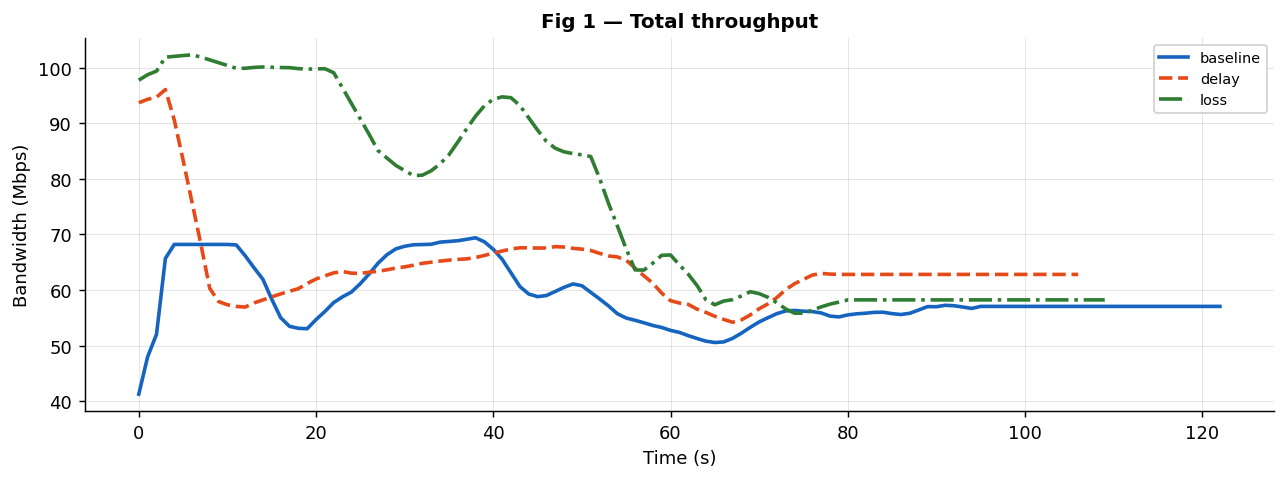

In [8]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

if TRIPLE_MODE:
    for lbl in labels:
        sub = df_util[df_util['label'] == lbl]
        tot = total_ts(sub, 'bw_mbps', 'sum')
        ax.plot(tot.index, smooth(tot),
                color=LABEL_COLOR[lbl], ls=LABEL_LS[lbl], lw=LABEL_LW, label=lbl)
else:
    for i, p in enumerate(active_paths):
        s = path_ts(df_util, p, 'bw_mbps')
        ax.plot(s.index, smooth(s),
                color=PATH_COLORS[i % len(PATH_COLORS)],
                ls=PATH_LS[i % len(PATH_LS)], lw=1.5, label=f'path={p}')
    tot = total_ts(df_util, 'bw_mbps', 'sum')
    ax.plot(tot.index, smooth(tot), color='black', lw=2.5,
            alpha=0.55, ls='-', label='total')

add_tc_markers(ax, which=())
finish_ax(ax, 'Bandwidth (Mbps)', 'Fig 1 — Total throughput')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_bandwidth.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## Figure 2 — OWD (ms)


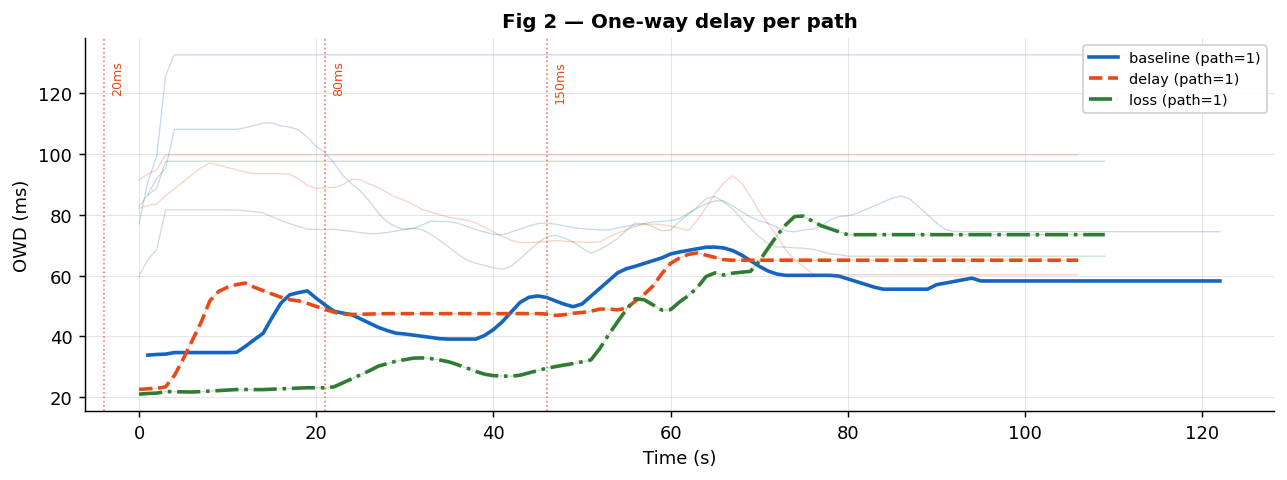

In [9]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

if TRIPLE_MODE:
    for lbl in labels:
        sub = df_util[df_util['label'] == lbl]
        c   = LABEL_COLOR[lbl]
        for p in active_paths:
            s = path_ts(sub, p, 'owd_ms')
            if not s.empty:
                ax.plot(s.index, smooth(s), color=c, lw=0.7, alpha=0.25)
        s_pri = path_ts(sub, PRIMARY_PATH, 'owd_ms')
        if not s_pri.empty:
            ax.plot(s_pri.index, smooth(s_pri),
                    color=c, ls=LABEL_LS[lbl], lw=LABEL_LW,
                    label=f'{lbl} (path={PRIMARY_PATH})')
else:
    for i, p in enumerate(active_paths):
        s = path_ts(df_util, p, 'owd_ms')
        ax.plot(s.index, smooth(s),
                color=PATH_COLORS[i % len(PATH_COLORS)],
                ls=PATH_LS[i % len(PATH_LS)], lw=1.8, label=f'path={p}')

add_tc_markers(ax, which=('delay',))
finish_ax(ax, 'OWD (ms)', 'Fig 2 — One-way delay per path')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_owd.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## Figure 3 — Utility U


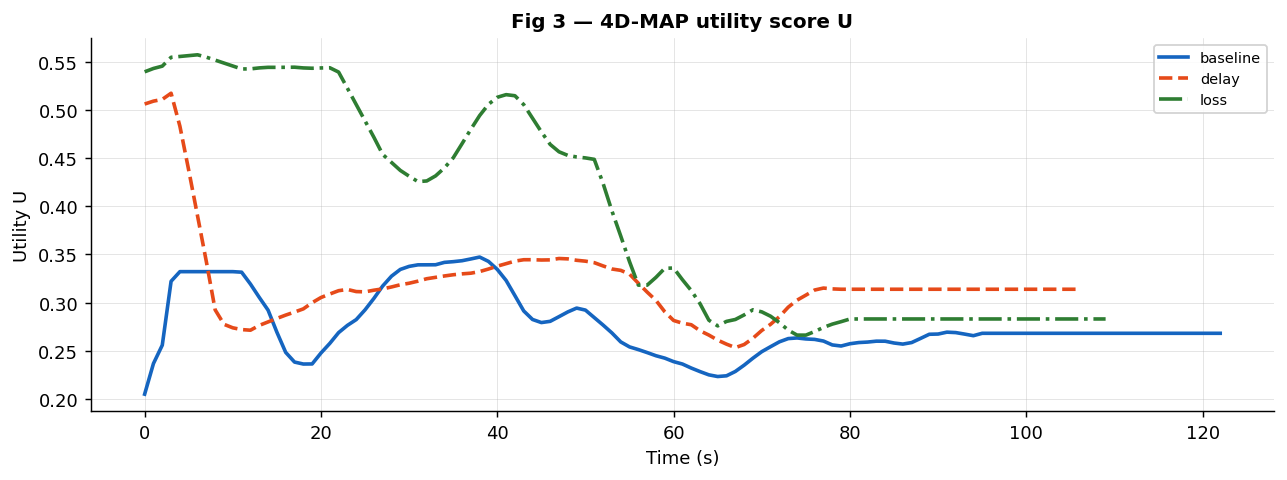

In [10]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

if TRIPLE_MODE:
    for lbl in labels:
        sub = df_util[df_util['label'] == lbl]
        tot = total_ts(sub, 'U', 'sum')
        ax.plot(tot.index, smooth(tot),
                color=LABEL_COLOR[lbl], ls=LABEL_LS[lbl], lw=LABEL_LW, label=lbl)
else:
    for i, p in enumerate(active_paths):
        s = path_ts(df_util, p, 'U')
        ax.plot(s.index, smooth(s),
                color=PATH_COLORS[i % len(PATH_COLORS)],
                ls=PATH_LS[i % len(PATH_LS)], lw=1.5, label=f'path={p}')
    tot = total_ts(df_util, 'U', 'sum')
    ax.plot(tot.index, smooth(tot), color='black', lw=2.5,
            alpha=0.55, ls='-', label='total U')

add_tc_markers(ax, which=())
finish_ax(ax, 'Utility U', 'Fig 3 — 4D-MAP utility score U')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_utility_U.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## Figure 4 — Loss Rate


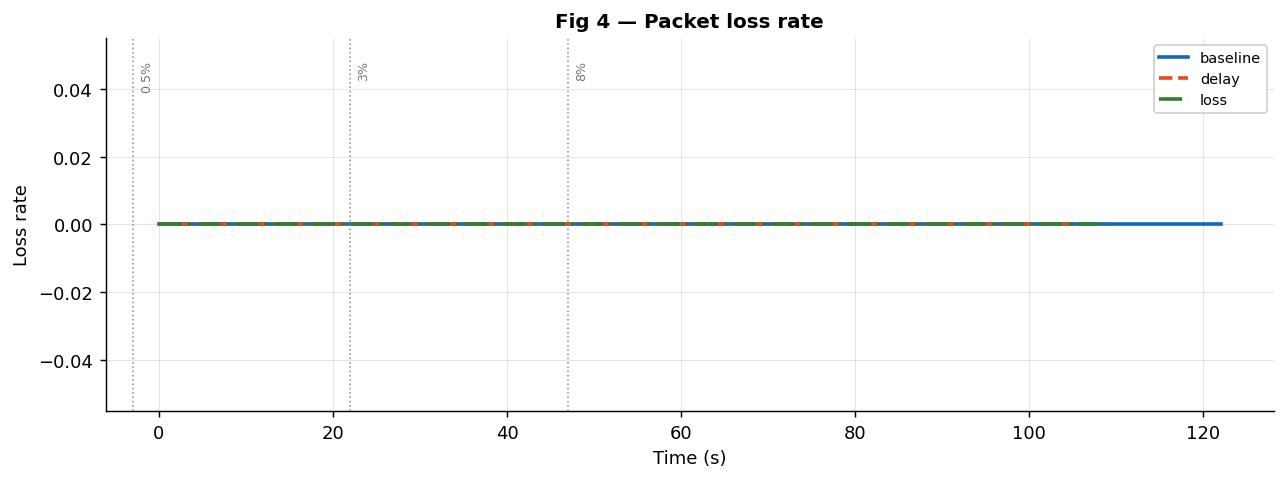

In [11]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

if TRIPLE_MODE:
    for lbl in labels:
        sub   = df_util[df_util['label'] == lbl]
        worst = total_ts(sub, 'loss', 'max')
        ax.plot(worst.index, smooth(worst),
                color=LABEL_COLOR[lbl], ls=LABEL_LS[lbl], lw=LABEL_LW, label=lbl)
else:
    for i, p in enumerate(active_paths):
        s = path_ts(df_util, p, 'loss')
        ax.plot(s.index, smooth(s),
                color=PATH_COLORS[i % len(PATH_COLORS)],
                ls=PATH_LS[i % len(PATH_LS)], lw=1.8, label=f'path={p}')

add_tc_markers(ax, which=('loss',), loss_color=TC_LOSS_VLINE_COLOR)
finish_ax(ax, 'Loss rate', 'Fig 4 — Packet loss rate')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_loss.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## Bonus — Utility components G / D / L


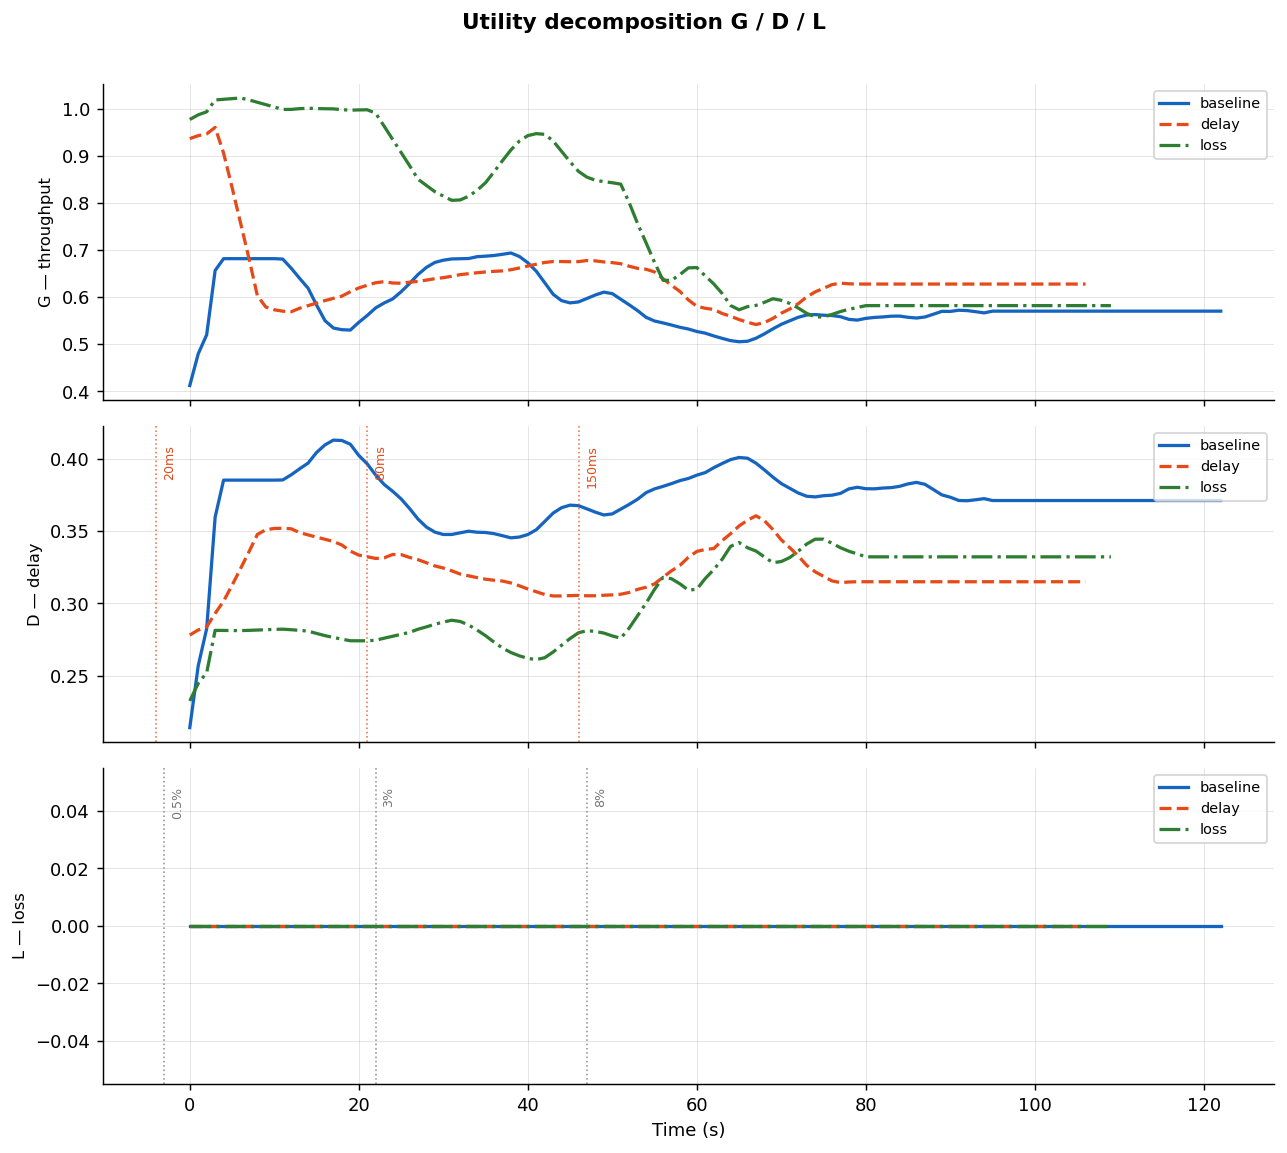

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
components = [('G', 'G — throughput'), ('D', 'D — delay'), ('L', 'L — loss')]

for ax, (comp, comp_title) in zip(axes, components):
    if TRIPLE_MODE:
        for lbl in labels:
            sub = df_util[df_util['label'] == lbl]
            tot = total_ts(sub, comp, 'sum')
            ax.plot(tot.index, smooth(tot),
                    color=LABEL_COLOR[lbl], ls=LABEL_LS[lbl], lw=1.8, label=lbl)
    else:
        for i, p in enumerate(active_paths):
            s = path_ts(df_util, p, comp)
            ax.plot(s.index, smooth(s),
                    color=PATH_COLORS[i % len(PATH_COLORS)],
                    ls=PATH_LS[i % len(PATH_LS)], lw=1.6, label=f'path={p}')
    if comp == 'G':
        add_tc_markers(ax, which=())
    elif comp == 'D':
        add_tc_markers(ax, which=('delay',))
    else:
        add_tc_markers(ax, which=('loss',), loss_color=TC_LOSS_VLINE_COLOR)
    ax.set_ylabel(comp_title, fontsize=9)
    ax.grid(True, lw=0.35, alpha=0.5)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle('Utility decomposition G / D / L', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURES_DIR / 'fig5_GDL.pdf', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
for p in sorted(FIGURES_DIR.glob('*.pdf')):
    print(p.name)


fig1_bandwidth.pdf
fig2_owd.pdf
fig3_utility_U.pdf
fig4_loss.pdf
fig5_GDL.pdf
